Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Path to dataset files: C:\Users\Riddhi\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3
['DailyDelhiClimateTest.csv', 'DailyDelhiClimateTrain.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB
None
          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802209   1011.104548
std       7.348103    16.769652    

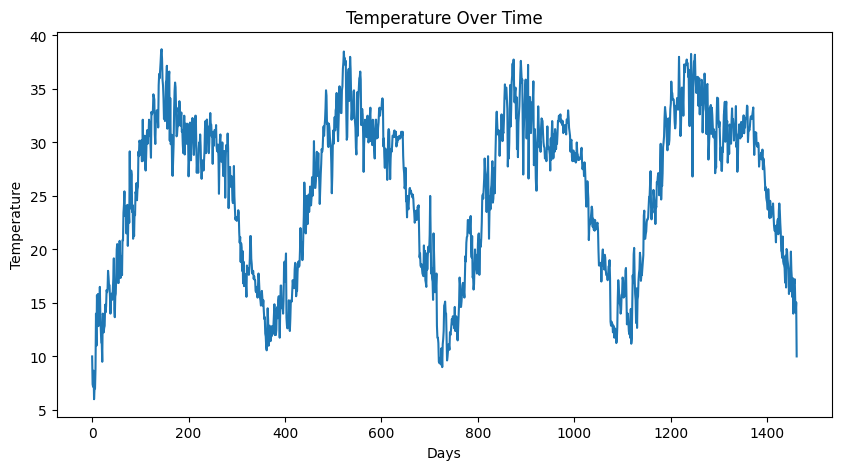

Shape of X: (1432, 30, 1)
Epoch 1/20


C:\Users\Riddhi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0465
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0072
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0059
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0056
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0053
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0052
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0051
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0053
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0049
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0047
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0047
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0046
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0045
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0045
Epoch 15/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0046
Epoch 16/20
36/

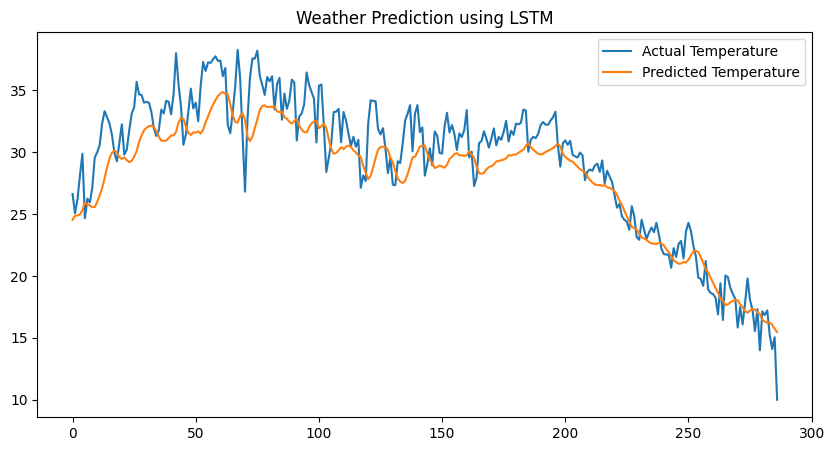

RMSE: 2.4227021261375943


In [3]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)


import pandas as pd
import os

print(os.listdir(path))


df = pd.read_csv(os.path.join(path, "DailyDelhiClimateTrain.csv"))

df.head()


print(df.info())
print(df.describe())


import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['meantemp'])
plt.title("Temperature Over Time")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.show()


from sklearn.preprocessing import MinMaxScaler
import numpy as np

data = df[['meantemp']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


X = []
y = []

time_step = 30

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)


X = X.reshape(X.shape[0], X.shape[1], 1)

print("Shape of X:", X.shape)


split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))


model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32
)


predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label='Actual Temperature')
plt.plot(predictions, label='Predicted Temperature')

plt.legend()
plt.title("Weather Prediction using LSTM")
plt.show()


from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)

print("RMSE:", rmse)